<a href="https://colab.research.google.com/github/grgpratibha/test/blob/master/HarryPorterScrape_episodes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Scraping HarryPorter Episodes

scrape information from the :

[HArry porter](https://en.wikipedia.org/wiki/Harry_Potter_(film_series))

## installing necessary modules

In [ ]:
! pip install requests beautifulsoup4
! pip install nltk wordcloud

## Mounting the drive and setting the working directory

In [2]:
from google.colab import drive
drive.mount('/content/drive/')

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


In [3]:
import os

os.chdir('/content/drive/MyDrive/Colab Notebooks')

## Scraping data from wikipedia page using requests and BeautiulSoup

In [4]:
# importing the necessary modules
import requests
from bs4 import BeautifulSoup
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from nltk.corpus import stopwords
import nltk
import re
import matplotlib.pyplot as plt

from collections import Counter
import string
import pandas as pd

In [5]:
# get the stopwords from NLTK
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

## Browser's Developer Tool -> inspect element -> style class of desired table??

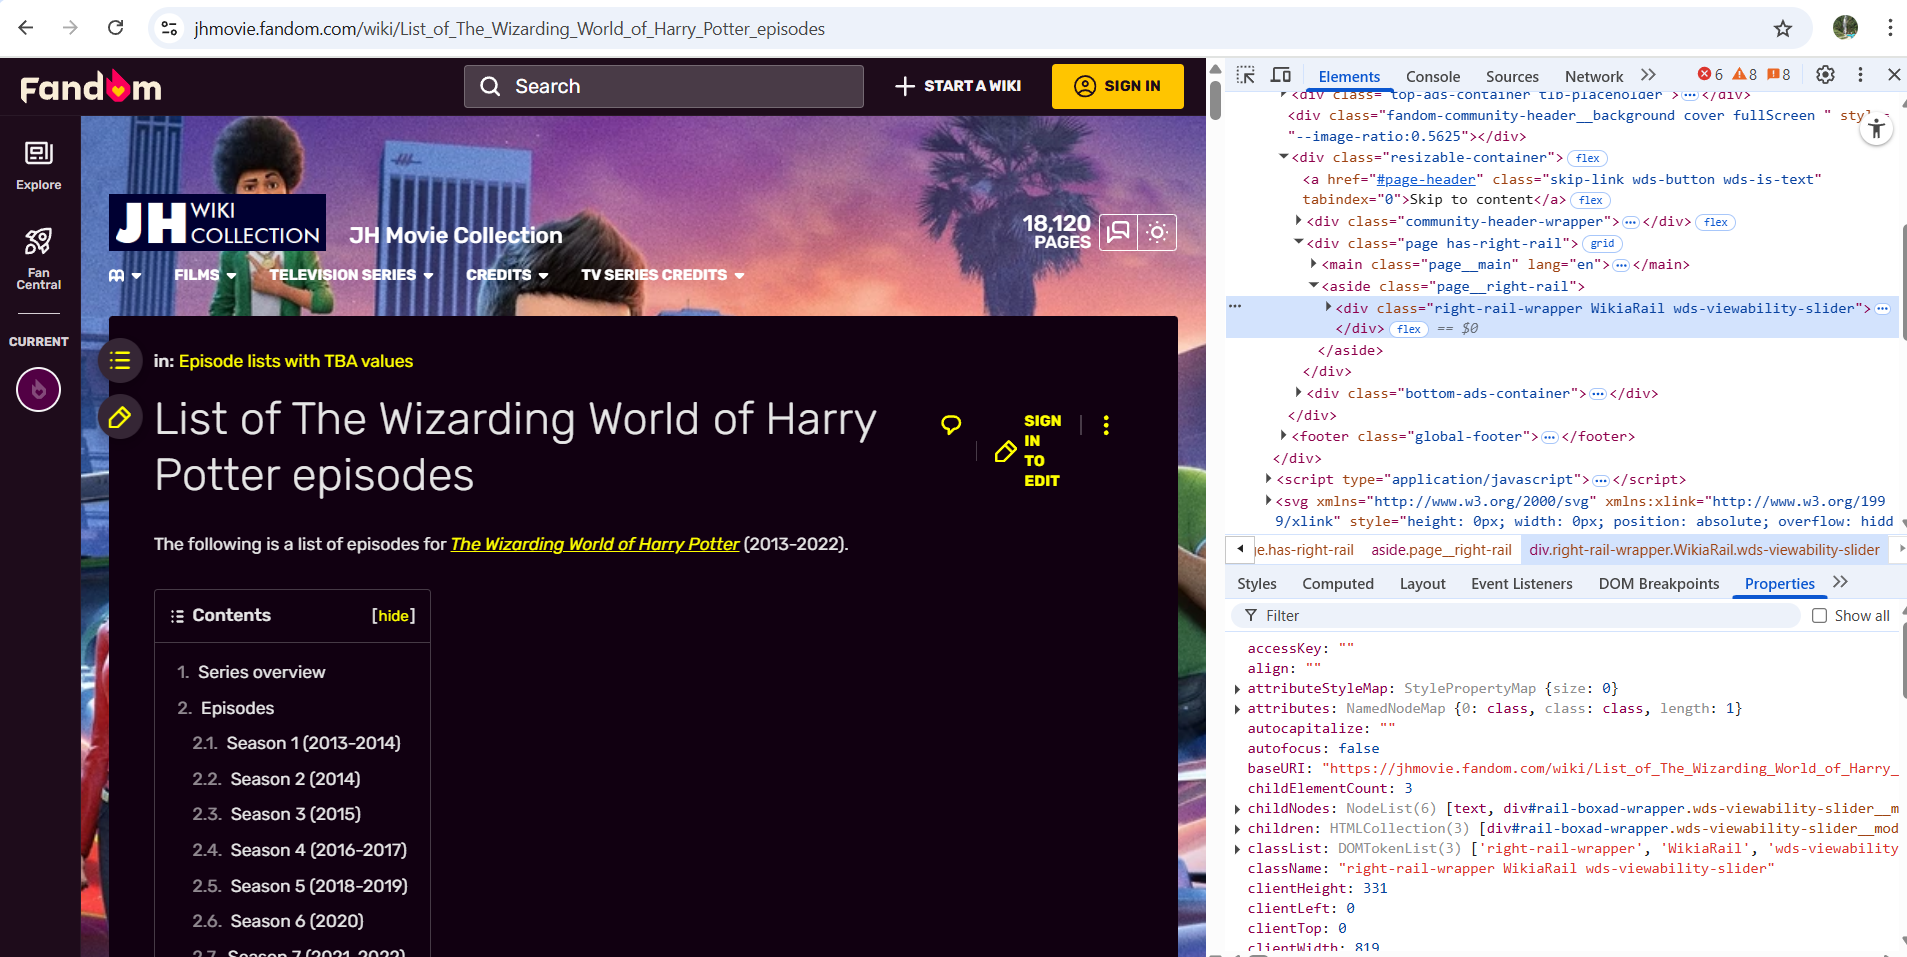

can we use any of the following?

```
soup.find_all('table', class_='wikiepisodetable')  

soup.find_all('table', class_='wikitable plainrowheaders wikiepisodetable')

soup.find_all('table', attrs={'class': ['wikitable', 'wikiepisodetable']})

```

In [6]:
# Define our functions here
def save_episode_data( html_soup):

    episodes = []
    #ep_tables = html_soup.find_all('table', class_='wikiepisodetable')
    ep_tables = html_soup.find_all('table', class_='wikitable plainrowheaders wikiepisodetable')

    for table in ep_tables:
        headers = []
        rows = table.find_all('tr')
    # Start by fetching the header cells from the first row to determine
    # the field names
        for header in table.find('tr').find_all('th'):
            headers.append(header.text)
    # print(headers)
    # Then go through all the rows except the first one
        for row in table.find_all('tr')[1:]:
            values = []
            # And get the column cells, the first one being inside a th-tag
            for col in row.find_all(['th','td']):
                values.append(col.text)
            if values:
                episode_dict = {}
                for i in range(len(values)):
                  episode_dict[headers[i]]= values[i]
                episodes.append(episode_dict)

    return episodes


# display word cloud from text
def print_wordcloud(str_text):

    wordcloud = WordCloud(width=1000, height=500, background_color='white').generate(str_text)
    # now display the word cloud
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.show()

    return

# function to extract specific field values
def get_field_episodes(field_name, episodes):
    str_text = ''
    list_values = [(dd.get(field_name, 'N/A')) for dd in episodes]
    for tt in list_values:
        if tt != 'N/A':
            str_text += tt + ' '
    return str_text

#load saved file
def read_html_file(file_path):
    try:
        with open(file_path, "r", encoding="utf-8") as file:
            html_content = file.read()
        return html_content
    except FileNotFoundError:
        print(f"File '{file_path}' not found.")
        return None


# read the text from the HTML content
def extract_text_from_html(html_content):

    soup = BeautifulSoup(html_content, 'html.parser')
    soup_text = soup.get_text()

    return soup_text


# Now, clean the text by removing stopwords and special characters
def clean_text(text):

    # remove special characters and numbers
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = text.lower()  # change to lowercase

    # tokenize the text and remove stopwords
    stop_words = set(stopwords.words('english'))
    words = text.split()
    filtered_words = [word for word in words if word not in stop_words and len(word) > 2]

    # finally, join the filtered words back into a single string
    filtered_text = " ".join(filtered_words)

    return filtered_text


def get_top_n_words(text, n=10):
    # Convert text to lowercase and remove punctuation
    text = text.lower().translate(str.maketrans('', '', string.punctuation))

    # Tokenize the text into words
    words = text.split()

    # Remove stopwords
    stop_words = set(stopwords.words('english'))
    filtered_words = [word for word in words if word not in stop_words]

    # Count word frequencies
    word_freq = Counter(filtered_words)

    # Return the top N most common words
    return word_freq.most_common(n)


Lets do the webscraping and processing the data

In [7]:
#1. scrape the URL and save the html contents
url = "https://jhmovie.fandom.com/wiki/List_of_The_Wizarding_World_of_Harry_Potter_episodes"
response = requests.get(url)
if response.status_code != 200:
    exit()


html_contents = response.text
# save the html page contents
with open("harryporter_episodes.html", "w", encoding="utf-8") as file:
    file.write(html_contents)
print("HTML Page's content saved locally to 'harryporter_episodes.html'.")


html_soup = BeautifulSoup(html_contents, 'html.parser')

# Storing the episode list
episodes = save_episode_data( html_soup)

# Show the results

for i in range(len(episodes)):
    print(episodes[i])
    break # if we want to print all data then comment this line

HTML Page's content saved locally to 'harryporter_episodes.html'.
{'No.overall': '1', 'No. inseason': '1', 'Title': '"The Boy Who Lived"', 'Directed by': 'TBA', 'Written by': 'TBA', 'Storyboard by': 'TBA', 'Original air date': 'October\xa027,\xa02013\xa0(2013-10-27)', 'Prod.code': 'TBA', 'US viewers(millions)': 'TBA'}


## Using pickle to dump the data in 'episodes'

In [8]:
import pickle
# Filepath to save the pickle file
pickle_file = "harryporter_episodes.pkl"

# Save the `episodes` list to a pickle file
with open(pickle_file, "wb") as file:
    pickle.dump(episodes, file)

pickle_file

'harryporter_episodes.pkl'

## Loding the 'episodes' back

In [9]:
# Step 3: Loading Variables
loaded_episodes = None

# Open the file in binary mode
with open(pickle_file, 'rb') as file:
    # Deserialize and retrieve the variable from the file
    loaded_episodes = pickle.load(file)

print("The variable 'data' has been loaded successfully.")

print("Loaded Data:", loaded_episodes)

The variable 'data' has been loaded successfully.
Loaded Data: [{'No.overall': '1', 'No. inseason': '1', 'Title': '"The Boy Who Lived"', 'Directed by': 'TBA', 'Written by': 'TBA', 'Storyboard by': 'TBA', 'Original air date': 'October\xa027,\xa02013\xa0(2013-10-27)', 'Prod.code': 'TBA', 'US viewers(millions)': 'TBA'}, {'No.overall': '2', 'No. inseason': '2', 'Title': '"The Vanishing Glass"', 'Directed by': 'TBA', 'Written by': 'TBA', 'Storyboard by': 'TBA', 'Original air date': 'November\xa03,\xa02013\xa0(2013-11-03)', 'Prod.code': 'TBA', 'US viewers(millions)': 'TBA'}, {'No.overall': '3', 'No. inseason': '3', 'Title': '"The Letters from No One"', 'Directed by': 'TBA', 'Written by': 'TBA', 'Storyboard by': 'TBA', 'Original air date': 'November\xa010,\xa02013\xa0(2013-11-10)', 'Prod.code': 'TBA', 'US viewers(millions)': 'TBA'}, {'No.overall': '4', 'No. inseason': '4', 'Title': '"The Keeper of the Keys"', 'Directed by': 'TBA', 'Written by': 'TBA', 'Storyboard by': 'TBA', 'Original air dat

In [10]:
# lets display some loaded data
loaded_episodes[:1]

[{'No.overall': '1',
  'No. inseason': '1',
  'Title': '"The Boy Who Lived"',
  'Directed by': 'TBA',
  'Written by': 'TBA',
  'Storyboard by': 'TBA',
  'Original air date': 'October\xa027,\xa02013\xa0(2013-10-27)',
  'Prod.code': 'TBA',
  'US viewers(millions)': 'TBA'}]

In [11]:
# lets display some loaded data
loaded_episodes[:2]

[{'No.overall': '1',
  'No. inseason': '1',
  'Title': '"The Boy Who Lived"',
  'Directed by': 'TBA',
  'Written by': 'TBA',
  'Storyboard by': 'TBA',
  'Original air date': 'October\xa027,\xa02013\xa0(2013-10-27)',
  'Prod.code': 'TBA',
  'US viewers(millions)': 'TBA'},
 {'No.overall': '2',
  'No. inseason': '2',
  'Title': '"The Vanishing Glass"',
  'Directed by': 'TBA',
  'Written by': 'TBA',
  'Storyboard by': 'TBA',
  'Original air date': 'November\xa03,\xa02013\xa0(2013-11-03)',
  'Prod.code': 'TBA',
  'US viewers(millions)': 'TBA'}]

In [12]:
# lets display some loaded data
loaded_episodes[:4]

[{'No.overall': '1',
  'No. inseason': '1',
  'Title': '"The Boy Who Lived"',
  'Directed by': 'TBA',
  'Written by': 'TBA',
  'Storyboard by': 'TBA',
  'Original air date': 'October\xa027,\xa02013\xa0(2013-10-27)',
  'Prod.code': 'TBA',
  'US viewers(millions)': 'TBA'},
 {'No.overall': '2',
  'No. inseason': '2',
  'Title': '"The Vanishing Glass"',
  'Directed by': 'TBA',
  'Written by': 'TBA',
  'Storyboard by': 'TBA',
  'Original air date': 'November\xa03,\xa02013\xa0(2013-11-03)',
  'Prod.code': 'TBA',
  'US viewers(millions)': 'TBA'},
 {'No.overall': '3',
  'No. inseason': '3',
  'Title': '"The Letters from No One"',
  'Directed by': 'TBA',
  'Written by': 'TBA',
  'Storyboard by': 'TBA',
  'Original air date': 'November\xa010,\xa02013\xa0(2013-11-10)',
  'Prod.code': 'TBA',
  'US viewers(millions)': 'TBA'},
 {'No.overall': '4',
  'No. inseason': '4',
  'Title': '"The Keeper of the Keys"',
  'Directed by': 'TBA',
  'Written by': 'TBA',
  'Storyboard by': 'TBA',
  'Original air dat

## Lets display the wordclouds

In [13]:
str_titles = get_field_episodes('Title', loaded_episodes)
str_desc = get_field_episodes('No.', loaded_episodes) # check if this filed can get the descriptions!!!


Wordclouds of Titles only


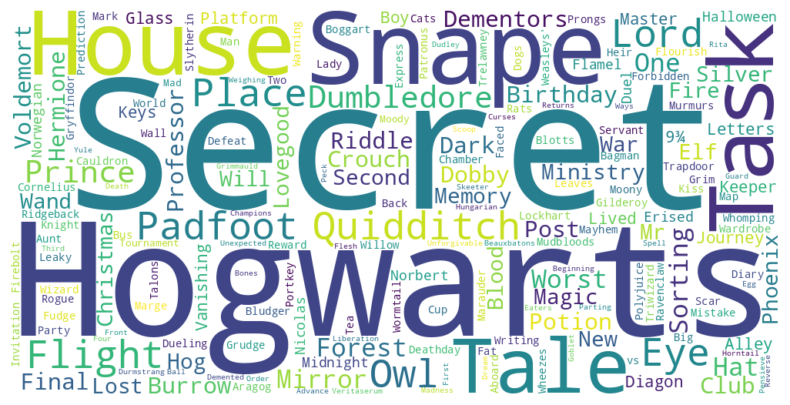

In [14]:
print ("Wordclouds of Titles only")
print_wordcloud(str_titles)



In [ ]:
print ("Wordclouds of Description ")
print_wordcloud(str_desc)


Wordclouds of Description 


ValueError: We need at least 1 word to plot a word cloud, got 0.

In [ ]:

print ("Wordclouds of Titles and Description")
print_wordcloud(str_titles +' '+ str_desc)

Wordclouds of Titles and Description


ValueError: We need at least 1 word to plot a word cloud, got 0.

In [15]:

# Convert  list of dictionaries (loaded_episodes) into a pandas DataFrame.
# Parameters: episodloaded_episodeses (list): List of dictionaries, where each dictionary is an episode with fields.

df_episode= pd.DataFrame(loaded_episodes)
df_episode.head()

,No.overall,No. inseason,Title,Directed by,Written by,Storyboard by,Original air date,Prod.code,US viewers(millions)
0,1,1,"""The Boy Who Lived""",TBA,TBA,TBA,"October 27, 2013 (2013-10-27)",TBA,TBA
1,2,2,"""The Vanishing Glass""",TBA,TBA,TBA,"November 3, 2013 (2013-11-03)",TBA,TBA
2,3,3,"""The Letters from No One""",TBA,TBA,TBA,"November 10, 2013 (2013-11-10)",TBA,TBA
3,4,4,"""The Keeper of the Keys""",TBA,TBA,TBA,"November 17, 2013 (2013-11-17)",TBA,TBA
4,5,5,"""Diagon Alley""",TBA,TBA,TBA,"November 24, 2013 (2013-11-24)",TBA,TBA


In [16]:
import pandas as pd

def convert_to_dataframe_with_description(episodes):
    """
    Converts list of dictionaries to a cleaned DataFrame by extracting descriptions
    from alternate rows and assigning them to a new 'Description' column.

    Parameters:
        episodes (list): List of dictionaries parsed from web.

    Returns:
        pd.DataFrame: Cleaned DataFrame with descriptions properly assigned.
    """
    # Step 1: Convert to DataFrame
    df = pd.DataFrame(episodes)

    # Step 2: Reset index in case it's not default
    df.reset_index(drop=True, inplace=True)

    # Step 3: Create empty column 'Description'
    df['Description'] = None

    # Step 4: Loop through even rows and pull description from the next row (if available)
    for i in range(0, len(df), 2):
        if i+1 < len(df) and pd.isna(df.iloc[i+1, 1]):  # Assuming 1st col of description row is not numeric
            df.at[i, 'Description'] = str(df.iloc[i+1, 0]).strip()

    # Step 5: Drop the odd-numbered rows (1, 3, 5, ...) containing only descriptions
    df_cleaned = df.drop(index=[i for i in range(1, len(df), 2)])

    # Step 6: Reset index
    df_cleaned.reset_index(drop=True, inplace=True)

    return df_cleaned
df_episode = convert_to_dataframe_with_description(loaded_episodes)
df_episode.head()

,No.overall,No. inseason,Title,Directed by,Written by,Storyboard by,Original air date,Prod.code,US viewers(millions),Description
0,1,1,"""The Boy Who Lived""",TBA,TBA,TBA,"October 27, 2013 (2013-10-27)",TBA,TBA,None
1,3,3,"""The Letters from No One""",TBA,TBA,TBA,"November 10, 2013 (2013-11-10)",TBA,TBA,None
2,5,5,"""Diagon Alley""",TBA,TBA,TBA,"November 24, 2013 (2013-11-24)",TBA,TBA,None
3,7,7,"""The Sorting Hat""",TBA,TBA,TBA,"December 8, 2013 (2013-12-08)",TBA,TBA,None
4,9,9,"""The Midnight Duel""",TBA,TBA,TBA,"December 22, 2013 (2013-12-22)",TBA,TBA,None


from matplotlib import pyplot as plt
import seaborn as sns
_df_0.groupby('No.overall').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
import seaborn as sns
_df_1.groupby('No. inseason').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
import seaborn as sns
_df_2.groupby('Title').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
import seaborn as sns
_df_3.groupby('Original air date').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

...

from matplotlib import pyplot as plt
import seaborn as sns
def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  counted = (series['Original air date']
                .value_counts()
              .reset_index(name='counts')
              .rename({'index': 'Original air date'}, axis=1)
              .sort_values('Original air date', ascending=True))
  xs = counted['Original air date']
  ys = counted['counts']
  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = _df_6.sort_values('Original air date', ascending=True)
for i, (series_name, series) in enumerate(df_sorted.groupby('Title')):
  _plot_series(series, series_name, i)
  fig.legend(title='Title', bbox_to_anchor=(1, 1), loc='upper left')
sns.despine(fig=fig, ax=ax)
plt.xlabel('Original air date')
_ = plt.ylabel('count()')

from matplotlib import pyplot as plt
import seaborn as sns
def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  counted = (series['Original air date']
                .value_counts()
              .reset_index(name='counts')
              .rename({'index': 'Original air date'}, axis=1)
              .sort_values('Original air date', ascending=True))
  xs = counted['Original air date']
  ys = counted['counts']
  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = _df_7.sort_values('Original air date', ascending=True)
for i, (series_name, series) in enumerate(df_sorted.groupby('Original air date')):
  _plot_series(series, series_name, i)
  fig.legend(title='Original air date', bbox_to_anchor=(1, 1), loc='upper left')
sns.despine(fig=fig, ax=ax)
plt.xlabel('Original air date')
_ = plt.ylabel('count()')

from matplotlib import pyplot as plt
import seaborn as sns
import pandas as pd
plt.subplots(figsize=(8, 8))
df_2dhist = pd.DataFrame({
    x_label: grp['No. inseason'].value_counts()
    for x_label, grp in _df_8.groupby('No.overall')
})
sns.heatmap(df_2dhist, cmap='viridis')
plt.xlabel('No.overall')
_ = plt.ylabel('No. inseason')

from matplotlib import pyplot as plt
import seaborn as sns
import pandas as pd
plt.subplots(figsize=(8, 8))
df_2dhist = pd.DataFrame({
    x_label: grp['Title'].value_counts()
    for x_label, grp in _df_9.groupby('No. inseason')
})
sns.heatmap(df_2dhist, cmap='viridis')
plt.xlabel('No. inseason')
_ = plt.ylabel('Title')

from matplotlib import pyplot as plt
import seaborn as sns
import pandas as pd
plt.subplots(figsize=(8, 8))
df_2dhist = pd.DataFrame({
    x_label: grp['Original air date'].value_counts()
    for x_label, grp in _df_10.groupby('Title')
})
sns.heatmap(df_2dhist, cmap='viridis')
plt.xlabel('Title')
_ = plt.ylabel('Original air date')

In [17]:
df_episode.to_csv('harryporter_episodes.csv', index=False)

Word Cloud from entire html text


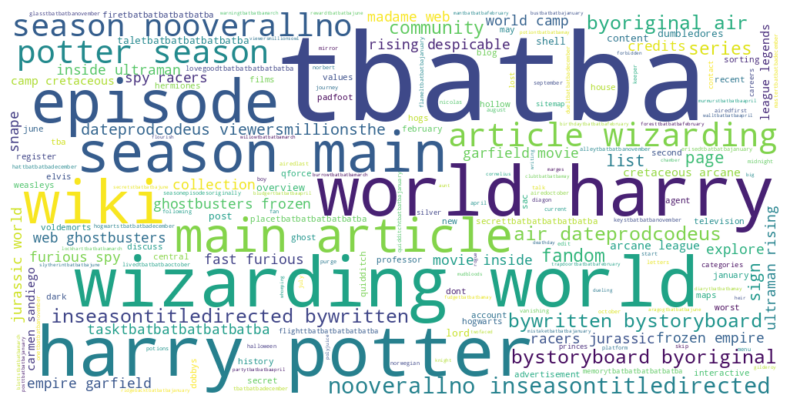

In [18]:
# laod the saved HTML content from 'mayday_episodes.html'

# Step 1: Read the HTML file
saved_file ='harryporter_episodes.html'
html_content = read_html_file(saved_file)
text = extract_text_from_html(html_content)
cleaned_text = clean_text(text)

print ("Word Cloud from entire html text")
print_wordcloud(cleaned_text)



In [19]:

print ("Most frequent 5 words")
top_5_words = get_top_n_words(cleaned_text, n=5)
print(top_5_words)


print ("Most frequent 10 words")
top_10_words = get_top_n_words(cleaned_text, n=10)
print(top_10_words)

Most frequent 5 words
[('tbatba', 70), ('season', 21), ('world', 15), ('wizarding', 11), ('harry', 10)]
Most frequent 10 words
[('tbatba', 70), ('season', 21), ('world', 15), ('wizarding', 11), ('harry', 10), ('potter', 10), ('main', 9), ('wiki', 7), ('article', 7), ('nooverallno', 7)]


## lets play with our existing dataframe


In [20]:
df = df_episode #Both point to the same object (changes in df affect df_episode).



In [21]:
df = df_episode.copy() # Creates a new, independent copy (safe from modifying the original).


In [22]:
df.head()

,No.overall,No. inseason,Title,Directed by,Written by,Storyboard by,Original air date,Prod.code,US viewers(millions),Description
0,1,1,"""The Boy Who Lived""",TBA,TBA,TBA,"October 27, 2013 (2013-10-27)",TBA,TBA,None
1,3,3,"""The Letters from No One""",TBA,TBA,TBA,"November 10, 2013 (2013-11-10)",TBA,TBA,None
2,5,5,"""Diagon Alley""",TBA,TBA,TBA,"November 24, 2013 (2013-11-24)",TBA,TBA,None
3,7,7,"""The Sorting Hat""",TBA,TBA,TBA,"December 8, 2013 (2013-12-08)",TBA,TBA,None
4,9,9,"""The Midnight Duel""",TBA,TBA,TBA,"December 22, 2013 (2013-12-22)",TBA,TBA,None


In [23]:
df.head(2)


,No.overall,No. inseason,Title,Directed by,Written by,Storyboard by,Original air date,Prod.code,US viewers(millions),Description
0,1,1,"""The Boy Who Lived""",TBA,TBA,TBA,"October 27, 2013 (2013-10-27)",TBA,TBA,None
1,3,3,"""The Letters from No One""",TBA,TBA,TBA,"November 10, 2013 (2013-11-10)",TBA,TBA,None


In [24]:
df.tail(3)

,No.overall,No. inseason,Title,Directed by,Written by,Storyboard by,Original air date,Prod.code,US viewers(millions),Description
96,193,31,"""The Battle of Hogwarts""",TBA,TBA,TBA,TBA,TBA,TBA,None
97,195,33,"""The Prince's Tale""",TBA,TBA,TBA,TBA,TBA,TBA,None
98,197,35,"""King's Cross""",TBA,TBA,TBA,TBA,TBA,TBA,None


In [ ]:
# lets remove a column
df.drop('No.', axis=1, inplace=True)


KeyError: "['No.'] not found in axis"

In [26]:
# SLICING
df.loc[0:2,'Title']

,Title
0,"""The Boy Who Lived"""
1,"""The Letters from No One"""
2,"""Diagon Alley"""


In [25]:
# SLICING
df.loc[2:5,'Title']

,Title
2,"""Diagon Alley"""
3,"""The Sorting Hat"""
4,"""The Midnight Duel"""
5,"""Quidditch"""


In [27]:
# SLICING and seeing the difference between title and description
df.loc[2:5,'Description']

,Description
2,None
3,None
4,None
5,None


In [28]:
# SLICING
df.iloc[0:2,1]

,No. inseason
0,1
1,3


In [ ]:
# SLICING
df.iloc[0:2,:]

,No.overall,No. inseason,Title,Directed by,Written by,Storyboard by,Original air date,Prod.code,US viewers(millions),Description
0,1,1,"""The Boy Who Lived""",TBA,TBA,TBA,"October 27, 2013 (2013-10-27)",TBA,TBA,None
1,3,3,"""The Letters from No One""",TBA,TBA,TBA,"November 10, 2013 (2013-11-10)",TBA,TBA,None


In [29]:
# SLICING
df.iloc[:,0:2]

,No.overall,No. inseason
0,1,1
1,3,3
2,5,5
3,7,7
4,9,9
...,...,...
94,189,27
95,191,29
96,193,31
97,195,33


In [27]:
#installing spacy and networkx
'''
pip install spacy networkx matplotlib
python -m spacy download en_core_web_sm

#if above code does not work then try adding ! code before pip and python and rerun
'''

! pip install spacy networkx matplotlib
!python -m spacy download en_core_web_sm


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 107.5 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


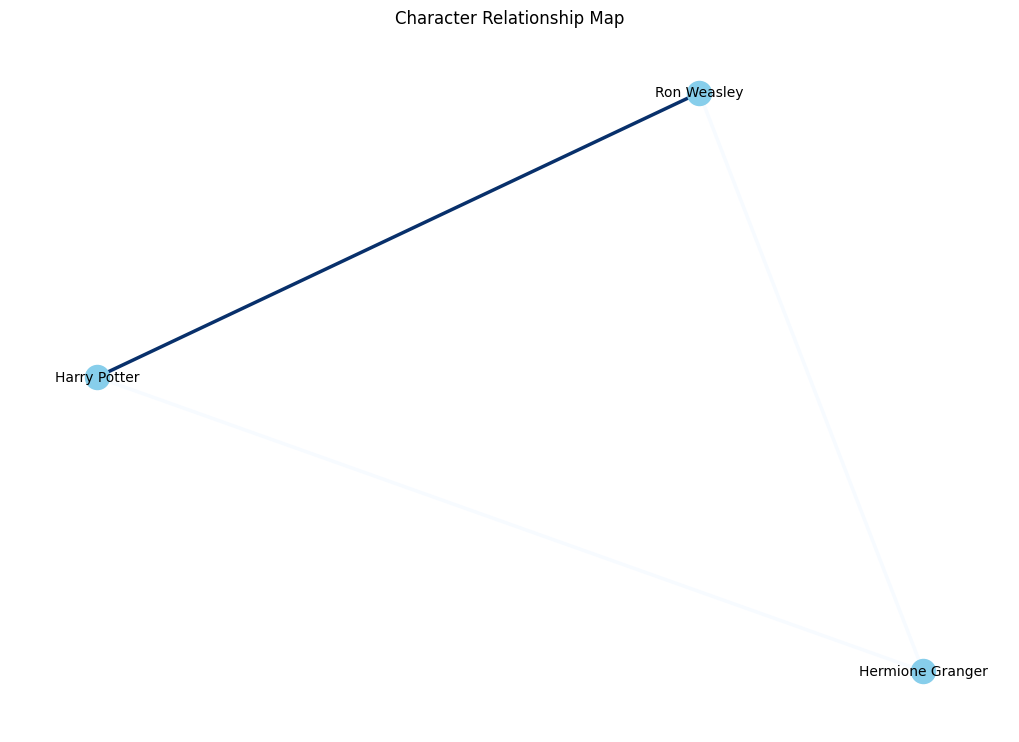

In [37]:
import spacy
import networkx as nx
import matplotlib.pyplot as plt
from collections import defaultdict
import re

# Load spaCy model
nlp = spacy.load("en_core_web_sm")

# Sample scraped data (replace this with your own)
episodes = [
   "Harry Potter was walking with Ron Weasley to Hogwarts. Hermione Granger joined them later.",
    "Draco Malfoy challenged Harry Potter to a duel. Ron Weasley tried to stop them.",
    "Hermione Granger and Professor Snape argued about a potion.",
]


#episodes=df_episode['Title']

# Extract character co-occurrence
co_occurrence = defaultdict(lambda: defaultdict(int))

for text in episodes:
    doc = nlp(text)
    people = [ent.text for ent in doc.ents if ent.label_ == "PERSON"]
    unique_people = list(set(people))  # avoid duplicate co-mentions
    for i in range(len(unique_people)):
        for j in range(i + 1, len(unique_people)):
            p1, p2 = unique_people[i], unique_people[j]
            co_occurrence[p1][p2] += 1
            co_occurrence[p2][p1] += 1

# Create graph
G = nx.Graph()

# Add edges
for p1, connections in co_occurrence.items():
    for p2, weight in connections.items():
        if weight > 0:
            G.add_edge(p1, p2, weight=weight)

# Draw graph
plt.figure(figsize=(10, 7))
pos = nx.spring_layout(G, k=0.5)
weights = [G[u][v]['weight'] for u, v in G.edges()]
nx.draw(G, pos, with_labels=True, node_color="skyblue", edge_color=weights,
        width=2.5, edge_cmap=plt.cm.Blues, font_size=10)
plt.title("Character Relationship Map")
plt.show()


In [34]:
! pip install nltk matplotlib


In [35]:
import nltk
nltk.download('vader_lexicon')


[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


True

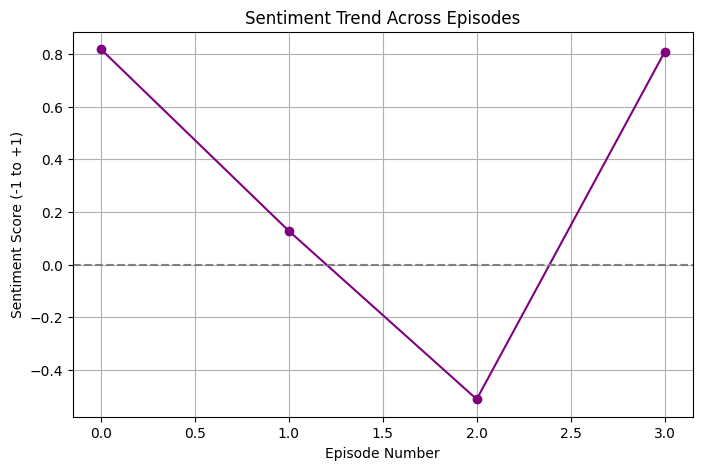

In [36]:
# SEntiment Analysis

from nltk.sentiment import SentimentIntensityAnalyzer
import matplotlib.pyplot as plt

# Sample data, Need to replace here with my code, how to??
episodes = [
    "Harry felt happy to be back at Hogwarts. He met Ron and Hermione with joy.",
    "There was a gloomy silence in the Great Hall. Dumbledore announced a tragic event.",
    "Harry was angry with Snape. He stormed out of the class.",
    "The students cheered as Gryffindor won the house cup!",
]

# Initialize sentiment analyzer
sia = SentimentIntensityAnalyzer()

# Analyze each episode
sentiment_scores = []
for episode in episodes:
    score = sia.polarity_scores(episode)["compound"]
    sentiment_scores.append(score)

# Plot sentiment over time
plt.figure(figsize=(8, 5))
plt.plot(sentiment_scores, marker='o', linestyle='-', color='purple')
plt.title("Sentiment Trend Across Episodes")
plt.xlabel("Episode Number")
plt.ylabel("Sentiment Score (-1 to +1)")
plt.grid(True)
plt.axhline(0, color='gray', linestyle='--')
plt.show()
